In [1]:
import torch

# ตรวจสอบและใช้งาน GPU ของชิป M4
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"รันโมเดลบน: {device}")

รันโมเดลบน: mps


In [2]:
import numpy as np
from scipy.io import loadmat

d1 = loadmat('../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR0dB_O1_60_Ant64/channel1.mat')['a']
d2 = loadmat('../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR0dB_O1_60_Ant64/channel2.mat')['b']
d3 = loadmat('../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR0dB_O1_60_Ant64/channel3.mat')['c']

data = np.concatenate((d1, d2, d3), axis=2).transpose(2, 0, 1)

d_r = data.real
d_i = data.imag
data_combined = np.concatenate((d_r, d_i), axis=2)

# Flatten
X = np.reshape(data_combined, (data_combined.shape[0], -1))

mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / (std + 1e-8) # 1e-8 prevents division by zero

print("Data normalization complete. Features now have Mean ≈ 0 and Std ≈ 1.")
# Load Label (One-hot encoding)
y = loadmat('../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR0dB_O1_60_Ant64/DLCB_output.mat')['onehot_label']

print(f"Input shape: {X.shape}")
print(f"Label shape: {y.shape}")

Data normalization complete. Features now have Mean ≈ 0 and Std ≈ 1.
Input shape: (53467, 4096)
Label shape: (53467, 64)


In [3]:
from torch.utils.data import DataLoader, TensorDataset

# 70% train, 30% test
split_idx = int(len(X) * 0.7)

# Training set: The first 70% of the user path
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Data Split Complete:")
print(f" - Training samples: {len(X_train)} (First 70%)")
print(f" - Testing samples:  {len(X_test)} (Last 30% - Future Path)")

train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
test_ds = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float())

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

Data Split Complete:
 - Training samples: 37426 (First 70%)
 - Testing samples:  16041 (Last 30% - Future Path)


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BeamPredictionDNN(nn.Module):
    def __init__(self, input_size, hidden_layers, nodes_per_layer, n_beams, dropout_rate):
        super(BeamPredictionDNN, self).__init__()
        self.layers = nn.ModuleList()
        
        # Input layer
        self.layers.append(nn.Linear(input_size, nodes_per_layer))
        self.layers.append(nn.Dropout(dropout_rate))
        
        # Hidden layers (4 layers)
        for _ in range(hidden_layers):
            self.layers.append(nn.Linear(nodes_per_layer, nodes_per_layer))
            self.layers.append(nn.Dropout(dropout_rate))
            
        # Output layer
        self.output_layer = nn.Linear(nodes_per_layer, n_beams)
        
        # Initialize weights (He Normal)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, x):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                x = F.relu(layer(x))
            else:
                x = layer(x) # Dropout
        
        # Final output uses ReLU as in your previous Keras code
        x = F.relu(self.output_layer(x))
        return x

In [6]:
model = BeamPredictionDNN(input_size=4096, hidden_layers=4, nodes_per_layer=512, n_beams=64, dropout_rate=0.05).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Trainable Params: {params}')

Total Trainable Params: 3181120


In [ ]:
epochs = 100
for epoch in range(epochs):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        # Use torch.max to find the best index of beam for CrossEntropyLoss
        loss = criterion(outputs, torch.max(labels, 1)[1])
        loss.backward()
        optimizer.step()
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

In [7]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        _, actual = torch.max(labels.data, 1)
        total += labels.size(0)
        correct += (predicted == actual).sum().item()
        
print(f'Average Accuracy on SNR 0dB: {100 * correct / total:.2f}%')

Average Accuracy on SNR 0dB: 72.26%


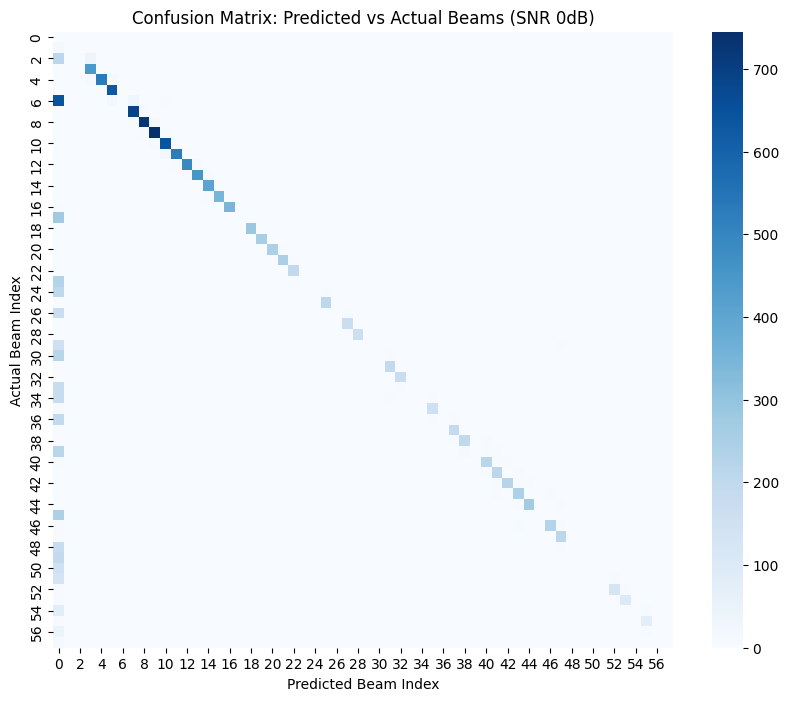

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# เก็บค่าผลลัพธ์ทั้งหมด
all_preds = []
all_actuals = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        _, actual = torch.max(labels, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_actuals.extend(actual.cpu().numpy())

# สร้าง Confusion Matrix
cm = confusion_matrix(all_actuals, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual Beams (SNR 0dB)')
plt.xlabel('Predicted Beam Index')
plt.ylabel('Actual Beam Index')
plt.show()

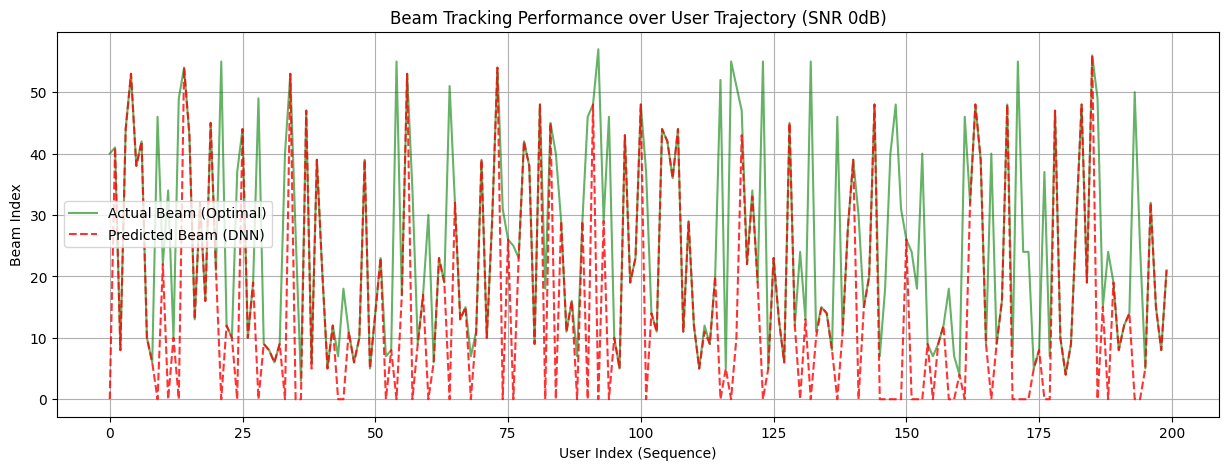

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(all_actuals[:200], 'g-', label='Actual Beam (Optimal)', alpha=0.6)
plt.plot(all_preds[:200], 'r--', label='Predicted Beam (DNN)', alpha=0.8)
plt.title('Beam Tracking Performance over User Trajectory (SNR 0dB)')
plt.xlabel('User Index (Sequence)')
plt.ylabel('Beam Index')
plt.legend()
plt.grid(True)
plt.show()